# Colab에서 한글 폰트 사용하기

## Step 1. Colab 런타임에 한글 폰트 설치

In [6]:
# Jupyter Notebook에서 리눅스 명령어를 실행
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,691 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and direc

## Step 2. Colab 런타임 재시작

# Step 3. `matplotlib.pyplot` 모듈에서 한글 폰트를 사용하도록 설정

In [1]:
import matplotlib.pyplot as plt

# pyplot 모듈에서 기본으로 사용할 폰트 계열을 나눔바른고딕으로 설정.
plt.rc("font", family="NanumBarunGothic")

# 한글 폰트 테스트

In [2]:
import pandas as pd
import seaborn as sns

In [3]:
df = pd.DataFrame(data={
    "시군구": ["서초구", "강남구", "송파구"],
    "가격": [9_000, 10_000, 8_500]
})
df

,시군구,가격
0,서초구,9000
1,강남구,10000
2,송파구,8500


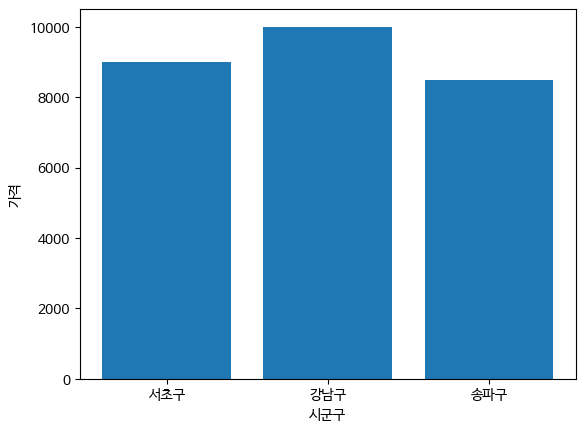

In [4]:
plt.bar(x=df["시군구"], height=df["가격"])

plt.xlabel("시군구")
plt.ylabel("가격")
plt.show()

# 아파트 실거래가 데이터 분석

*   [apt_202504.csv](https://github.com/JakeOh/202511_BD53/raw/refs/heads/main/datasets/apt_202504.csv) 파일을 읽고 DataFrame 생성
    *   첫 15줄은 파일 설명 문서 -> skip
    *   encoding 파라미터 설정(한글 인코딩: euc-kr)
    *   '가격' 컬럼에는 숫자 자릿수를 구분하는 comma가 사용되고 있음(예: 10,000)
        *   '가격' 컬럼은 숫자 타입이어야 함!
*   데이터 프레임 파악
    *   info, head, tail, describe, dtypes, ...
*   '시군구' 컬럼의 값을 이용해서, province 파생 변수(광역시도)를 만듦.
    *   '인천광역시 부평구 부평동' -> '인천광역시'
    *   '충청남도 천안시 서북구' -> '충청남도'
*   '시군구' 컬럼의 값을 이용해서, county 파생 변수(시/군/구)를 만듦.
    *   '인천광역시 부평구 부평동' -> '부평구'
    *   '충청남도 천안시 서북구' -> '천안시'
*   '계약년월' 컬럼의 값을 이용해서, year(계약년도), month(계약월) 파생 변수 만듦.
    *   202504 -> 2025(year), 4(month)
*   서울특별시 아파트들의 구별 아파트 가격의 개수, 평균, 최솟값, 최댓값
*   광역시도별 아파트 가격 개수, 평균, 최솟값, 최댓값
*   면적이  $84 m^2$  이상  $100 m^2$  미만의 서울특별시 아파트들 중에서, 구별 아파트 가격 개수, 평균, 최솟값, 최댓값
*   면적이 $84 m^2$ 이상 $100 m^2$ 미만의 아파트들 중에서, 광역시도별 아파트 가격 개수, 평균, 최솟값, 최댓값
    *   결과를 평균의 내림차순으로 정렬해서 출력
    *   결과를 최댓값의 내림차순으로 정렬해서 출력
    *   결과를 최솟값의 오름차순으로 정렬해서 출력

In [5]:
file_path = "https://github.com/JakeOh/202511_BD53/raw/refs/heads/main/datasets/apt_202504.csv"

In [22]:
apt = pd.read_csv(file_path, skiprows=15, encoding="euc-kr", index_col=0, thousands=",")

In [25]:
apt.head()

,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
NO,,,,,,,,,,,,,,,,,,,
1,인천광역시 부평구 부평동,140-6,140,6,신영(1동2동),48.0100,202504,30,17355,-,3,개인,개인,1983,길주남로90번길 45,-,중개거래,인천 부평구,-
2,인천광역시 미추홀구 주안동,1662,1662,0,주안파크자이더플래티넘,84.9937,202504,30,57800,-,23,개인,개인,2023,인하로222번길 20,-,중개거래,인천 미추홀구,-
3,인천광역시 미추홀구 주안동,1628,1628,0,주안역센트레빌,59.9813,202504,30,41000,-,22,개인,개인,2021,염전로 414,-,중개거래,인천 미추홀구,-
4,서울특별시 성동구 마장동,784,784,0,세림,84.9300,202504,30,73850,2,15,개인,개인,1986,마장로42길 16,-,직거래,-,25.04.30
5,서울특별시 동대문구 청량리동,60,60,0,한신,114.9500,202504,30,86200,-,20,개인,개인,1997,제기로 131,-,중개거래,서울 동대문구,-


In [26]:
apt.tail()

,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
NO,,,,,,,,,,,,,,,,,,,
36970,경기도 안산시 상록구 사동,1639,1639,0,그랑시티자이2차,84.9921,202504,1,69000,-,27,개인,개인,2020,해양5로 17,-,중개거래,"경기 시흥시, 경기 안산시 상록구",-
36971,경기도 안산시 상록구 사동,1639,1639,0,그랑시티자이2차,84.9712,202504,1,68000,-,5,개인,개인,2020,해양5로 17,-,중개거래,"경기 안산시 상록구, 서울 구로구",-
36972,경기도 안산시 상록구 사동,1506,1506,0,본오,38.1300,202504,1,12400,-,4,개인,개인,1992,선진로 108,-,중개거래,경기 안산시 상록구,-
36973,경기도 성남시 분당구 야탑동,156,156,0,목련마을(영남),84.9300,202504,1,86500,-,12,개인,개인,1995,판교로 669,-,중개거래,경기 성남시 분당구,-
36974,울산광역시 동구 전하동,682-1,682,1,삼전아이필하모니,84.5300,202504,1,21500,-,15,개인,개인,2006,방어진순환도로 733,-,중개거래,울산 동구,-


In [24]:
apt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36974 entries, 1 to 36974
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   시군구       36974 non-null  object 
 1   번지        36973 non-null  object 
 2   본번        36974 non-null  int64  
 3   부번        36974 non-null  int64  
 4   단지명       36974 non-null  object 
 5   전용면적(㎡)   36974 non-null  float64
 6   계약년월      36974 non-null  int64  
 7   계약일       36974 non-null  int64  
 8   거래금액(만원)  36974 non-null  int64  
 9   동         36974 non-null  object 
 10  층         36974 non-null  int64  
 11  매수자       36974 non-null  object 
 12  매도자       36974 non-null  object 
 13  건축년도      36974 non-null  int64  
 14  도로명       36974 non-null  object 
 15  해제사유발생일   36974 non-null  object 
 16  거래유형      36974 non-null  object 
 17  중개사소재지    36974 non-null  object 
 18  등기일자      36974 non-null  object 
dtypes: float64(1), int64(7), object(11)
memory usage: 5.6+ MB


In [27]:
apt.describe()

,본번,부번,전용면적(㎡),계약년월,계약일,거래금액(만원),층,건축년도
count,36974.000000,36974.000000,36974.000000,36974.0,36974.000000,3.697400e+04,36974.000000,36974.000000
mean,820.122951,3.142587,73.912814,202504.0,14.394088,4.348493e+04,10.057040,2006.137664
std,710.453648,38.857493,22.468251,0.0,8.364038,4.163910e+04,6.925089,10.891869
min,0.000000,0.000000,12.210000,202504.0,1.000000,1.200000e+03,-2.000000,1962.000000
25%,366.000000,0.000000,59.840000,202504.0,7.000000,1.820000e+04,5.000000,1997.000000
50%,703.000000,0.000000,75.532800,202504.0,14.000000,3.370000e+04,9.000000,2006.000000
75%,1080.000000,1.000000,84.950000,202504.0,21.000000,5.550000e+04,14.000000,2017.000000
max,7346.000000,5001.000000,244.470000,202504.0,30.000000,1.050000e+06,79.000000,2025.000000


In [32]:
# '계약년월' 컬럼을 datetime 타입으로 변환
# %Y: 4자리 연도, %m: 2자리 월
apt['계약년월'] = pd.to_datetime(apt['계약년월'], format='%Y%m').dt.to_period('M')

apt.tail()

,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
NO,,,,,,,,,,,,,,,,,,,
36970,경기도 안산시 상록구 사동,1639,1639,0,그랑시티자이2차,84.9921,2025-04,1,69000,-,27,개인,개인,2020,해양5로 17,-,중개거래,"경기 시흥시, 경기 안산시 상록구",-
36971,경기도 안산시 상록구 사동,1639,1639,0,그랑시티자이2차,84.9712,2025-04,1,68000,-,5,개인,개인,2020,해양5로 17,-,중개거래,"경기 안산시 상록구, 서울 구로구",-
36972,경기도 안산시 상록구 사동,1506,1506,0,본오,38.1300,2025-04,1,12400,-,4,개인,개인,1992,선진로 108,-,중개거래,경기 안산시 상록구,-
36973,경기도 성남시 분당구 야탑동,156,156,0,목련마을(영남),84.9300,2025-04,1,86500,-,12,개인,개인,1995,판교로 669,-,중개거래,경기 성남시 분당구,-
36974,울산광역시 동구 전하동,682-1,682,1,삼전아이필하모니,84.5300,2025-04,1,21500,-,15,개인,개인,2006,방어진순환도로 733,-,중개거래,울산 동구,-


In [33]:
apt['건축년도'] = pd.to_datetime(apt['건축년도'], format='%Y').dt.to_period('Y')
apt.head()

,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
NO,,,,,,,,,,,,,,,,,,,
1,인천광역시 부평구 부평동,140-6,140,6,신영(1동2동),48.0100,2025-04,30,17355,-,3,개인,개인,1983,길주남로90번길 45,-,중개거래,인천 부평구,-
2,인천광역시 미추홀구 주안동,1662,1662,0,주안파크자이더플래티넘,84.9937,2025-04,30,57800,-,23,개인,개인,2023,인하로222번길 20,-,중개거래,인천 미추홀구,-
3,인천광역시 미추홀구 주안동,1628,1628,0,주안역센트레빌,59.9813,2025-04,30,41000,-,22,개인,개인,2021,염전로 414,-,중개거래,인천 미추홀구,-
4,서울특별시 성동구 마장동,784,784,0,세림,84.9300,2025-04,30,73850,2,15,개인,개인,1986,마장로42길 16,-,직거래,-,25.04.30
5,서울특별시 동대문구 청량리동,60,60,0,한신,114.9500,2025-04,30,86200,-,20,개인,개인,1997,제기로 131,-,중개거래,서울 동대문구,-


In [34]:
apt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36974 entries, 1 to 36974
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype        
---  ------    --------------  -----        
 0   시군구       36974 non-null  object       
 1   번지        36973 non-null  object       
 2   본번        36974 non-null  int64        
 3   부번        36974 non-null  int64        
 4   단지명       36974 non-null  object       
 5   전용면적(㎡)   36974 non-null  float64      
 6   계약년월      36974 non-null  period[M]    
 7   계약일       36974 non-null  int64        
 8   거래금액(만원)  36974 non-null  int64        
 9   동         36974 non-null  object       
 10  층         36974 non-null  int64        
 11  매수자       36974 non-null  object       
 12  매도자       36974 non-null  object       
 13  건축년도      36974 non-null  period[Y-DEC]
 14  도로명       36974 non-null  object       
 15  해제사유발생일   36974 non-null  object       
 16  거래유형      36974 non-null  object       
 17  중개사소재지    36974 non-null  object    

*   '시군구' 컬럼의 값을 이용해서, province 파생 변수(광역시도)를 만듦.
    *   '인천광역시 부평구 부평동' -> '인천광역시'
    *   '충청남도 천안시 서북구' -> '충청남도'

In [40]:
apt["province"] = apt["시군구"].str.split(" ").str[0]

*   '시군구' 컬럼의 값을 이용해서, county 파생 변수(시/군/구)를 만듦.
    *   '인천광역시 부평구 부평동' -> '부평구'
    *   '충청남도 천안시 서북구' -> '천안시'

In [44]:
apt["county"] = apt["시군구"].str.split(" ").str[1]

*   '계약년월' 컬럼의 값을 이용해서, year(계약년도), month(계약월) 파생 변수 만듦.
    *   202504 -> 2025(year), 4(month)

In [47]:
apt["year"] = apt["계약년월"].dt.year
apt["month"] = apt["계약년월"].dt.month

In [48]:
apt.head()

,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,...,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,province,county,year,month
NO,,,,,,,,,,,,,,,,,,,,,
1,인천광역시 부평구 부평동,140-6,140,6,신영(1동2동),48.0100,2025-04,30,17355,-,...,1983,길주남로90번길 45,-,중개거래,인천 부평구,-,인천광역시,부평구,2025,4
2,인천광역시 미추홀구 주안동,1662,1662,0,주안파크자이더플래티넘,84.9937,2025-04,30,57800,-,...,2023,인하로222번길 20,-,중개거래,인천 미추홀구,-,인천광역시,미추홀구,2025,4
3,인천광역시 미추홀구 주안동,1628,1628,0,주안역센트레빌,59.9813,2025-04,30,41000,-,...,2021,염전로 414,-,중개거래,인천 미추홀구,-,인천광역시,미추홀구,2025,4
4,서울특별시 성동구 마장동,784,784,0,세림,84.9300,2025-04,30,73850,2,...,1986,마장로42길 16,-,직거래,-,25.04.30,서울특별시,성동구,2025,4
5,서울특별시 동대문구 청량리동,60,60,0,한신,114.9500,2025-04,30,86200,-,...,1997,제기로 131,-,중개거래,서울 동대문구,-,서울특별시,동대문구,2025,4


*   서울특별시 아파트들의 구별 아파트 가격의 개수, 평균, 최솟값, 최댓값

In [55]:
apt[apt["province"] == "서울특별시"].groupby(by=["county"])["거래금액(만원)"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
county,,,,
강남구,58,398812.068966,16000,1050000
강동구,237,112508.016878,10200,233000
강북구,77,67638.311688,8500,112000
강서구,242,84419.214876,9500,201000
관악구,150,79354.666667,10300,125000
광진구,116,128171.293103,13900,317000
구로구,208,70238.942308,10700,165000
금천구,47,62259.574468,8900,115500
노원구,308,59265.746753,29500,144000


In [57]:
apt[apt["province"] == "서울특별시"].pivot_table(values="거래금액(만원)", index="county", aggfunc=["count", "mean", "min", "max"])

,count,mean,min,max
,거래금액(만원),거래금액(만원),거래금액(만원),거래금액(만원)
county,,,,
강남구,58,398812.068966,16000,1050000
강동구,237,112508.016878,10200,233000
강북구,77,67638.311688,8500,112000
강서구,242,84419.214876,9500,201000
관악구,150,79354.666667,10300,125000
광진구,116,128171.293103,13900,317000
구로구,208,70238.942308,10700,165000
금천구,47,62259.574468,8900,115500


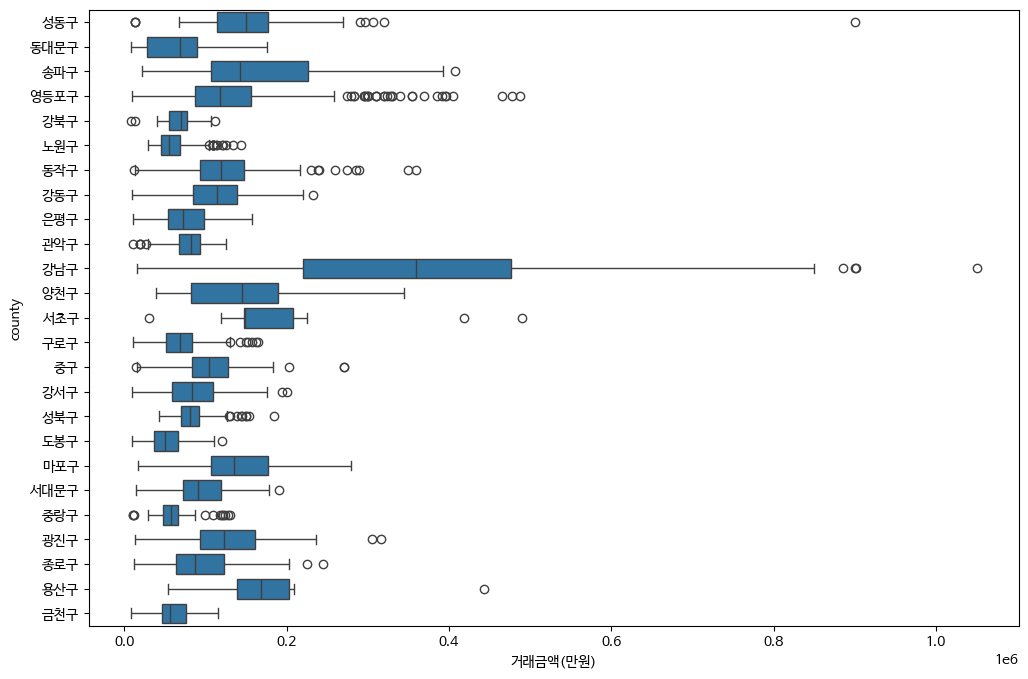

In [63]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=apt[apt["province"] == "서울특별시"], x="거래금액(만원)", y="county")

plt.show()

*   광역시도별 아파트 가격 개수, 평균, 최솟값, 최댓값

In [65]:
apt.groupby(by=["province"])["거래금액(만원)"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
province,,,,
강원특별자치도,1273,21880.036921,1500,95000
경기도,9733,51585.387342,3000,369000
경상남도,2559,24180.064088,1500,166000
경상북도,1701,18005.839506,1500,72000
광주광역시,1266,29210.827014,3650,168000
대구광역시,1780,33990.820787,2900,247500
대전광역시,1182,34653.980541,3480,210000
부산광역시,2134,39717.544049,2300,498000
서울특별시,4004,106616.144106,8500,1050000


In [66]:
apt.pivot_table(values="거래금액(만원)", index="province", aggfunc=["count", "mean", "min", "max"])

,count,mean,min,max
,거래금액(만원),거래금액(만원),거래금액(만원),거래금액(만원)
province,,,,
강원특별자치도,1273,21880.036921,1500,95000
경기도,9733,51585.387342,3000,369000
경상남도,2559,24180.064088,1500,166000
경상북도,1701,18005.839506,1500,72000
광주광역시,1266,29210.827014,3650,168000
대구광역시,1780,33990.820787,2900,247500
대전광역시,1182,34653.980541,3480,210000
부산광역시,2134,39717.544049,2300,498000


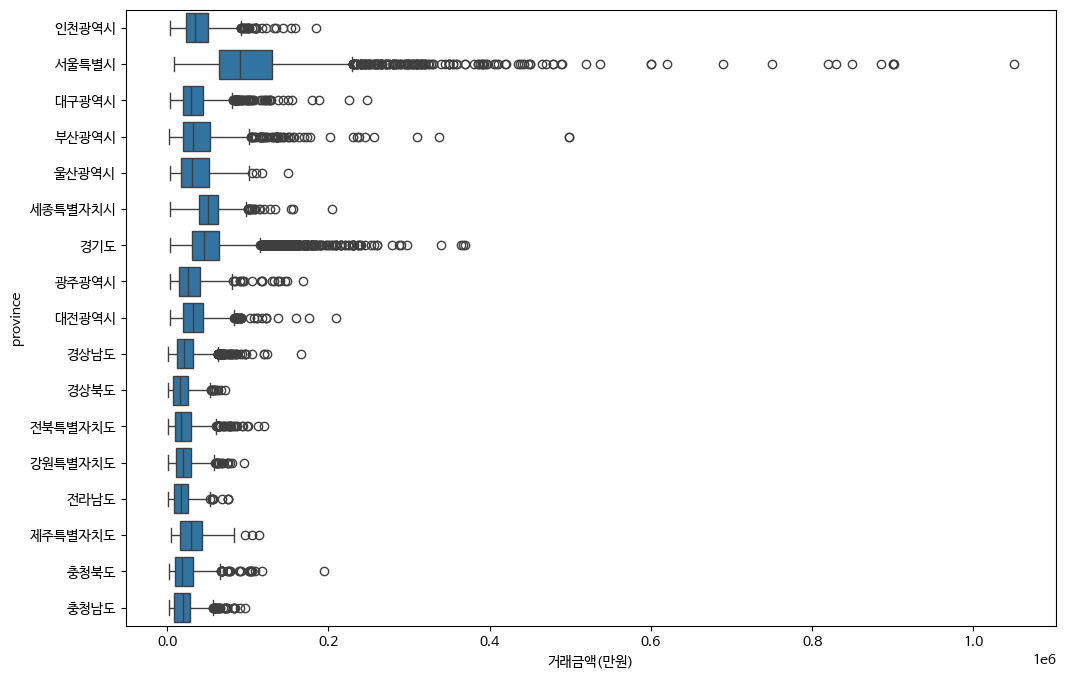

In [68]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=apt, x="거래금액(만원)", y="province")

plt.show()

면적이  $84 m^2$  이상  $100 m^2$  미만의 서울특별시 아파트들 중에서, 구별 아파트 가격 개수, 평균, 최솟값, 최댓값

In [70]:
apt.head()

,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,...,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,province,county,year,month
NO,,,,,,,,,,,,,,,,,,,,,
1,인천광역시 부평구 부평동,140-6,140,6,신영(1동2동),48.0100,2025-04,30,17355,-,...,1983,길주남로90번길 45,-,중개거래,인천 부평구,-,인천광역시,부평구,2025,4
2,인천광역시 미추홀구 주안동,1662,1662,0,주안파크자이더플래티넘,84.9937,2025-04,30,57800,-,...,2023,인하로222번길 20,-,중개거래,인천 미추홀구,-,인천광역시,미추홀구,2025,4
3,인천광역시 미추홀구 주안동,1628,1628,0,주안역센트레빌,59.9813,2025-04,30,41000,-,...,2021,염전로 414,-,중개거래,인천 미추홀구,-,인천광역시,미추홀구,2025,4
4,서울특별시 성동구 마장동,784,784,0,세림,84.9300,2025-04,30,73850,2,...,1986,마장로42길 16,-,직거래,-,25.04.30,서울특별시,성동구,2025,4
5,서울특별시 동대문구 청량리동,60,60,0,한신,114.9500,2025-04,30,86200,-,...,1997,제기로 131,-,중개거래,서울 동대문구,-,서울특별시,동대문구,2025,4


In [83]:
seoul_84_100 = apt[(84 <= apt["전용면적(㎡)"]) & (100 > apt["전용면적(㎡)"]) & (apt["province"] == "서울특별시")]

In [84]:
seoul_84_100.groupby(by=["county"])["거래금액(만원)"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
county,,,,
강남구,10,273350.000000,140000,381000
강동구,81,121548.148148,59700,204000
강북구,28,74869.642857,44000,96750
강서구,67,103374.626866,48500,151000
관악구,56,89050.000000,50000,125000
광진구,42,140078.571429,58000,205000
구로구,74,79764.864865,45000,158000
금천구,18,73416.666667,48000,115500
노원구,60,79140.000000,49000,122000


In [85]:
seoul_84_100.pivot_table(values="거래금액(만원)", index="county", aggfunc=["count", "mean", "min", "max"])

,count,mean,min,max
,거래금액(만원),거래금액(만원),거래금액(만원),거래금액(만원)
county,,,,
강남구,10,273350.000000,140000,381000
강동구,81,121548.148148,59700,204000
강북구,28,74869.642857,44000,96750
강서구,67,103374.626866,48500,151000
관악구,56,89050.000000,50000,125000
광진구,42,140078.571429,58000,205000
구로구,74,79764.864865,45000,158000
금천구,18,73416.666667,48000,115500


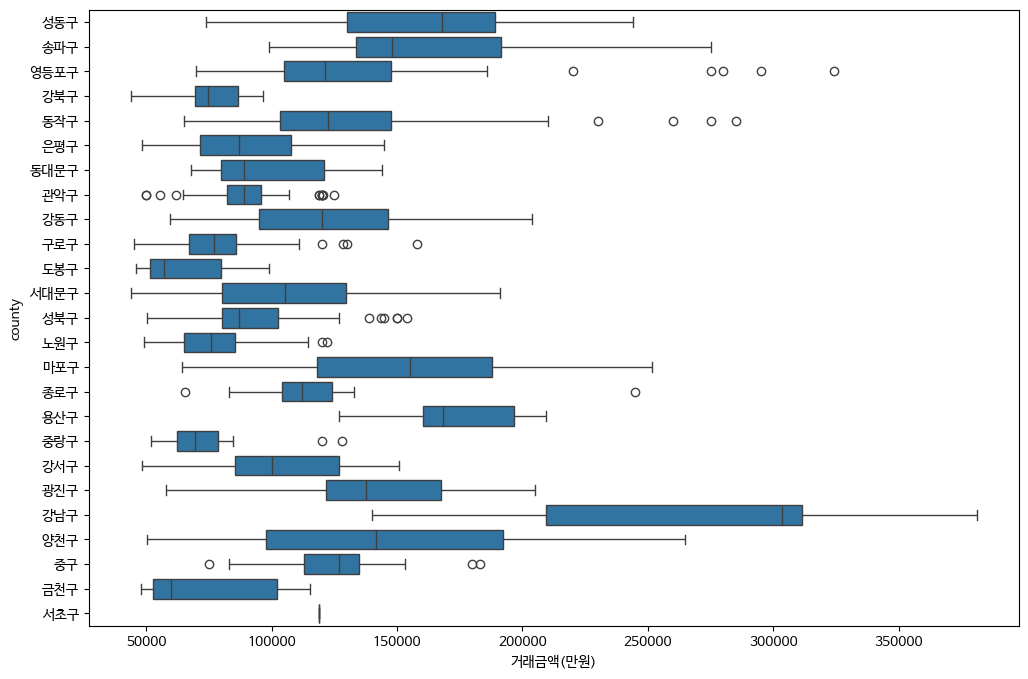

In [86]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=seoul_84_100, x="거래금액(만원)", y="county")

plt.show()

*   면적이 $84 m^2$ 이상 $100 m^2$ 미만의 아파트들 중에서, 광역시도별 아파트 가격 개수, 평균, 최솟값, 최댓값
    *   결과를 평균의 내림차순으로 정렬해서 출력
    *   결과를 최댓값의 내림차순으로 정렬해서 출력
    *   결과를 최솟값의 오름차순으로 정렬해서 출력

In [90]:
province_84_100 = apt[(84 <= apt["전용면적(㎡)"]) & (100 > apt["전용면적(㎡)"])].groupby(by=["province"])["거래금액(만원)"].agg(["count", "mean", "min", "max"])

province_84_100

,count,mean,min,max
province,,,,
강원특별자치도,450,30231.482222,5000,75000
경기도,3636,57321.139164,12000,253000
경상남도,1003,30878.494516,4700,98000
경상북도,594,25667.686869,3500,58500
광주광역시,545,35489.587156,9309,84000
대구광역시,813,40417.328413,12000,155000
대전광역시,458,42061.058952,13000,111000
부산광역시,743,48326.880215,10000,145000
서울특별시,1307,117148.783474,44000,381000


In [91]:
province_84_100.sort_values(by=["mean"], ascending=False)

,count,mean,min,max
province,,,,
서울특별시,1307,117148.783474,44000,381000
세종특별자치시,579,60490.846287,16500,134000
경기도,3636,57321.139164,12000,253000
부산광역시,743,48326.880215,10000,145000
인천광역시,759,46944.105402,13000,117500
울산광역시,602,44515.697674,6000,100500
제주특별자치도,49,42697.959184,16500,80000
대전광역시,458,42061.058952,13000,111000
대구광역시,813,40417.328413,12000,155000


In [92]:
province_84_100.sort_values(by=["max"], ascending=False)

,count,mean,min,max
province,,,,
서울특별시,1307,117148.783474,44000,381000
경기도,3636,57321.139164,12000,253000
대구광역시,813,40417.328413,12000,155000
부산광역시,743,48326.880215,10000,145000
세종특별자치시,579,60490.846287,16500,134000
인천광역시,759,46944.105402,13000,117500
대전광역시,458,42061.058952,13000,111000
울산광역시,602,44515.697674,6000,100500
경상남도,1003,30878.494516,4700,98000


In [93]:
province_84_100.sort_values(by=["min"])

,count,mean,min,max
province,,,,
경상북도,594,25667.686869,3500,58500
전북특별자치도,593,30469.994941,4000,79500
전라남도,475,24268.147368,4500,49300
경상남도,1003,30878.494516,4700,98000
강원특별자치도,450,30231.482222,5000,75000
울산광역시,602,44515.697674,6000,100500
충청남도,639,27286.211268,6700,84000
충청북도,539,32607.755102,7700,68500
광주광역시,545,35489.587156,9309,84000
